In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.sample(3)

,Survived,Age,Fare
424,0,18.0,20.2125
797,1,31.0,8.6833
205,0,2.0,10.4625


In [6]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [11]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [12]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [13]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

# Train test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Text(0.5, 1.0, 'Age QQ Plot')

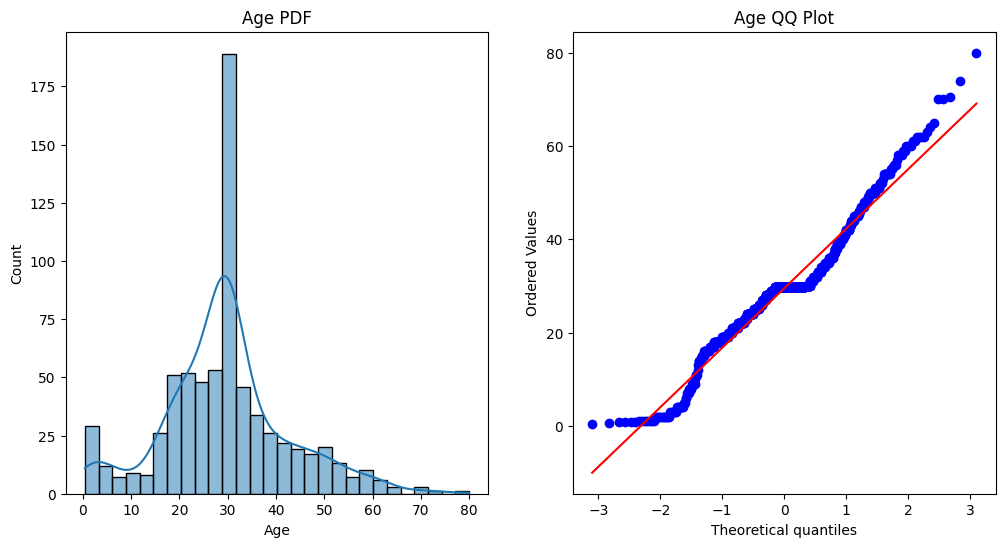

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.histplot(X_train['Age'], kde=True, ax=ax[0])
ax[0].set_title("Age PDF")

stats.probplot(X_train['Age'], dist="norm", plot=ax[1])
ax[1].set_title("Age QQ Plot")

Text(0.5, 1.0, 'Fare QQ Plot')

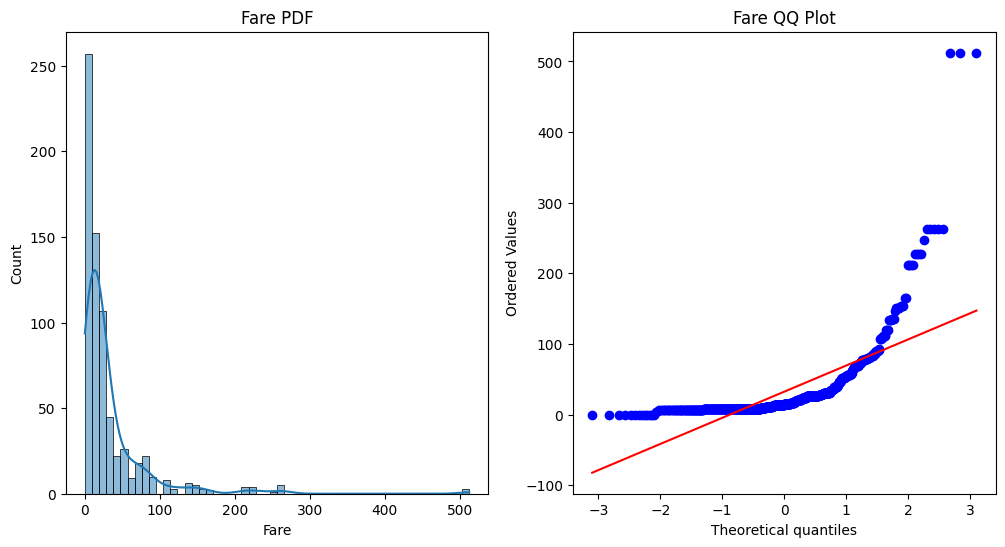

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.histplot(X_train['Fare'], kde=True, ax=ax[0])
ax[0].set_title("Fare PDF")

stats.probplot(X_train['Fare'], dist="norm", plot=ax[1])
ax[1].set_title("Fare QQ Plot")

In [18]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [19]:
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred1= clf1.predict(X_test)
y_pred2= clf2.predict(X_test)

print("Accuracy LR:", accuracy_score(y_test, y_pred1))
print("Accuracy DT:", accuracy_score(y_test, y_pred2))

Accuracy LR: 0.6480446927374302
Accuracy DT: 0.6703910614525139


# After Using Log Transformer

In [20]:
ltrf = FunctionTransformer(func=np.log1p)

In [21]:
X_train_transformed = ltrf.fit_transform(X_train)
X_test_transformed = ltrf.transform(X_test)

In [ ]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)
    
y_pred = clf1.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR:",accuracy_score(y_test, y_pred))
print("Accuracy DT:",accuracy_score(y_test, y_pred1))

Accuracy LR: 0.6815642458100558
Accuracy DT: 0.6759776536312849


# Cross validation 

In [23]:
X_transformed= ltrf.fit_transform(X)
clf1= LogisticRegression()
clf2= DecisionTreeClassifier()

cvs1= cross_val_score(clf1, X_transformed, y, scoring='accuracy', cv=5)
print("Accuracy LR:", cvs1)
print(np.mean(cvs1))

cvs2= cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=5)
print("Accuracy DT:", cvs2)
print(np.mean(cvs2))

Accuracy LR: [0.5698324  0.71348315 0.69101124 0.71348315 0.70224719]
0.6780114242671521
Accuracy DT: [0.63128492 0.66292135 0.62921348 0.69101124 0.62921348]
0.648728893352583


# Visualizing data before and after log transform

Text(0.5, 1.0, 'Age After Log Transform')

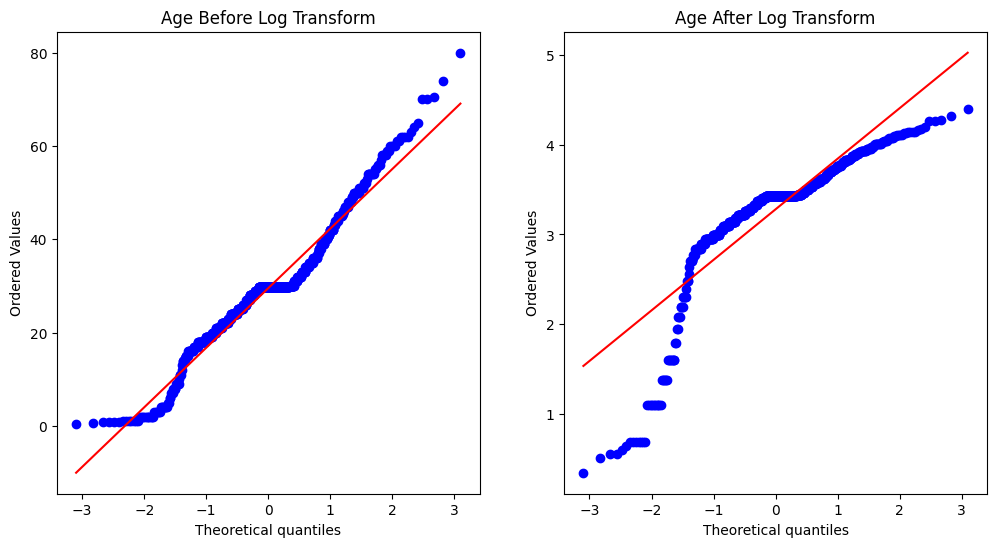

In [25]:
fig, ax= plt.subplots(1,2,figsize=(12,6))
stats.probplot(X_train['Age'], dist="norm", plot=ax[0])
ax[0].set_title("Age Before Log Transform")

stats.probplot(X_train_transformed['Age'], dist="norm", plot=ax[1])
ax[1].set_title("Age After Log Transform")

##### We can see that age was good before log transform as it was not right skewed data. (Log transform work well on right skewed data) 

Text(0.5, 1.0, 'Fare After Log Transform')

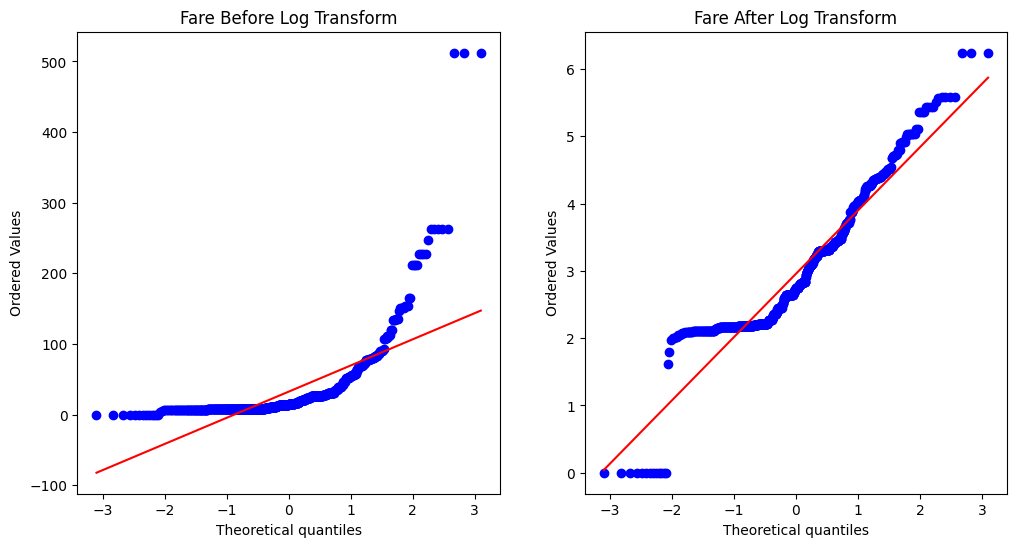

In [27]:
fig, ax= plt.subplots(1,2,figsize=(12,6))
stats.probplot(X_train['Fare'], dist="norm", plot=ax[0])
ax[0].set_title("Fare Before Log Transform")

stats.probplot(X_train_transformed['Fare'], dist="norm", plot=ax[1])
ax[1].set_title("Fare After Log Transform")

Text(0.5, 1.0, 'Age After Log Transform')

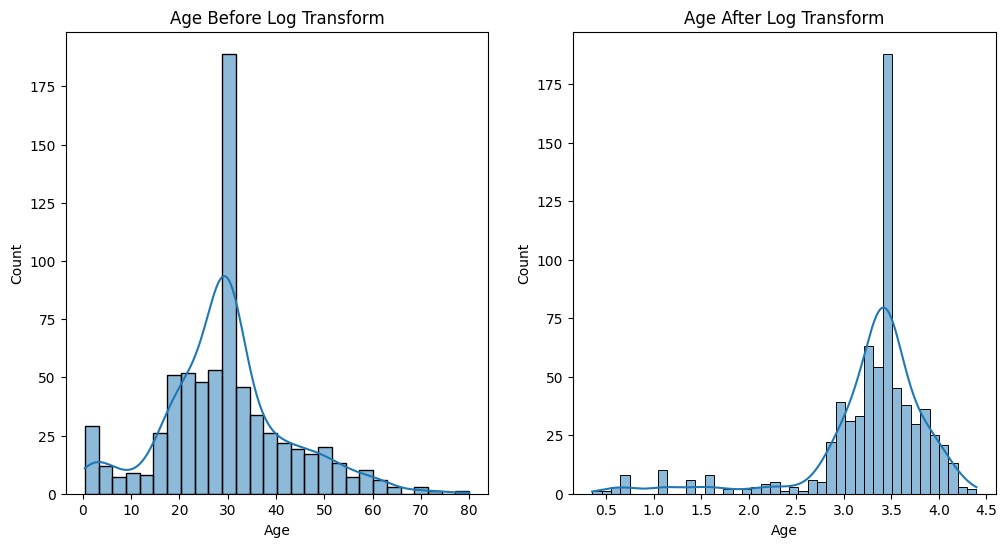

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(X_train['Age'], kde=True, ax=ax[0])
ax[0].set_title("Age Before Log Transform")

sns.histplot(X_train_transformed['Age'], kde=True, ax=ax[1])
ax[1].set_title("Age After Log Transform")


Text(0.5, 1.0, 'Fare After Log Transform')

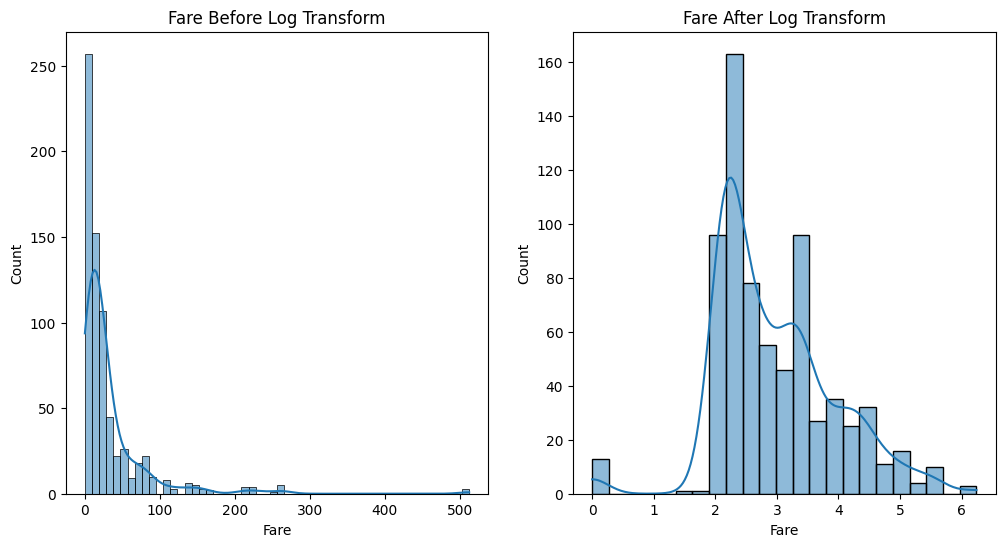

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(X_train['Fare'], kde=True, ax=ax[0])
ax[0].set_title("Fare Before Log Transform")

sns.histplot(X_train_transformed['Fare'], kde=True, ax=ax[1])
ax[1].set_title("Fare After Log Transform")